# Práctica Final NLP
## Notebook 3: Entrenamiento y Test



# Instalación de librerías

In [1]:
!pip install scikit-learn tensorflow

# Imports

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split         # para dividir en train y test
from sklearn.feature_extraction.text import TfidfVectorizer  # para vectorizar el texto con TF-IDF
from sklearn.feature_selection import chi2                   # para ver las palabras más discriminantes
from sklearn.linear_model import LogisticRegression          # modelo ML de clase
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve  # métricas

from tensorflow.keras.models import Sequential               # para construir el modelo capa a capa
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout  # capas del modelo
from tensorflow.keras.preprocessing.text import Tokenizer    # tokenizador de Keras
from tensorflow.keras.utils import pad_sequences             # para igualar la longitud de las secuencias

import warnings
warnings.filterwarnings('ignore')

# 1. Carga del dataset preprocesado

In [3]:
df = pd.read_csv('amazon_sentiment_preprocessed.csv')
df.head()

,text,rating,label,text_clean
0,The seller I bought it from sold it to me with...,5.0,1,seller bought sold brand new condition else sa...
1,"Ok, here are the reasons this game is BAD!.1. ...",1.0,0,ok reason game bad one graphic good plus level...
2,"For years now,gamers have said that this is on...",2.0,0,year gamers said one greatest game ever made u...
3,When 3D fighters first entered with Virtua Fig...,5.0,1,3d fighter first entered virtua fighter impres...
4,"When I first played Super Mario 64 as a kid, I...",5.0,1,first played super mario sixty-four kid amazed...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   text        5000 non-null   object 
 1   rating      5000 non-null   float64
 2   label       5000 non-null   int64  
 3   text_clean  5000 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 156.4+ KB


In [5]:
# Me quedo con las filas que tienen texto limpio
df = df.dropna(subset=['text_clean']).reset_index(drop=True)
print(f'Reviews disponibles: {len(df)}')

Reviews disponibles: 5000


# 2. División train / test


In [6]:
#Divido train y test
X_train, X_test, y_train, y_test = train_test_split(
    df['text_clean'],
    df['label'],
    train_size=0.75,
    test_size=0.25,
    random_state=42, # Para la reproducibilidad.
    shuffle=True
)

print(f'Train: {len(X_train)} muestras')
print(f'Test:  {len(X_test)} muestras')

Train: 3750 muestras
Test:  1250 muestras


# 3. Vectorización con TF-IDF

U `TfitilizodfVectorizer` igual que en el notebook 09 de clase.

TF-IDF da más peso a las palabras que son frecuentes en un documento pero raras en el corpus general, lo que las hace más discriminantes que una simple bolsa de palabras.

Parámetros (mismos que en clase):
- `max_df=0.95` → ignoro palabras que aparecen en más del 95% de los documentos (demasiado comunes)
- `min_df=3` → ignoro palabras que aparecen en menos de 3 documentos (demasiado raras)
- `max_features=2500` → me quedo con las 2500 palabras más relevantes
- `strip_accents='ascii'` → elimina acentos
- `ngram_range=(1,1)` → solo unigramas

In [7]:
cv = TfidfVectorizer(
    max_df=0.95,
    min_df=3,
    max_features=2500,
    strip_accents='ascii',
    ngram_range=(1, 1)
)
cv.fit(X_train)

TfidfVectorizer(max_df=0.95, max_features=2500, min_df=3, strip_accents='ascii')

In [8]:
print(list(cv.vocabulary_.items())[:20])

[('recent', np.int64(1787)), ('game', np.int64(928)), ('opinion', np.int64(1538)), ('fairly', np.int64(793)), ('average', np.int64(156)), ('wind', np.int64(2444)), ('latest', np.int64(1242)), ('actually', np.int64(24)), ('good', np.int64(976)), ('oot', np.int64(1535)), ('plain', np.int64(1629)), ('incredible', np.int64(1127)), ('play', np.int64(1639)), ('link', np.int64(1283)), ('child', np.int64(363)), ('young', np.int64(2494)), ('man', np.int64(1337)), ('quest', np.int64(1735)), ('defeat', np.int64(558)), ('ganon', np.int64(936))]


In [9]:
print(len(cv.vocabulary_))

2500


In [10]:
# Transformamos train y test con el vocabulario aprendido en train
# Importante: solo fit en train, transform en ambos para no hacer data leakage
X_train_ = cv.transform(X_train)
X_test_  = cv.transform(X_test)

## 3.1 Palabras más discriminantes con Chi-cuadrado

El test chi-cuadrado mide la dependencia entre cada palabra y la clase (positiva/negativa).
Las palabras con mayor chi2 son las más útiles para discriminar entre clases.

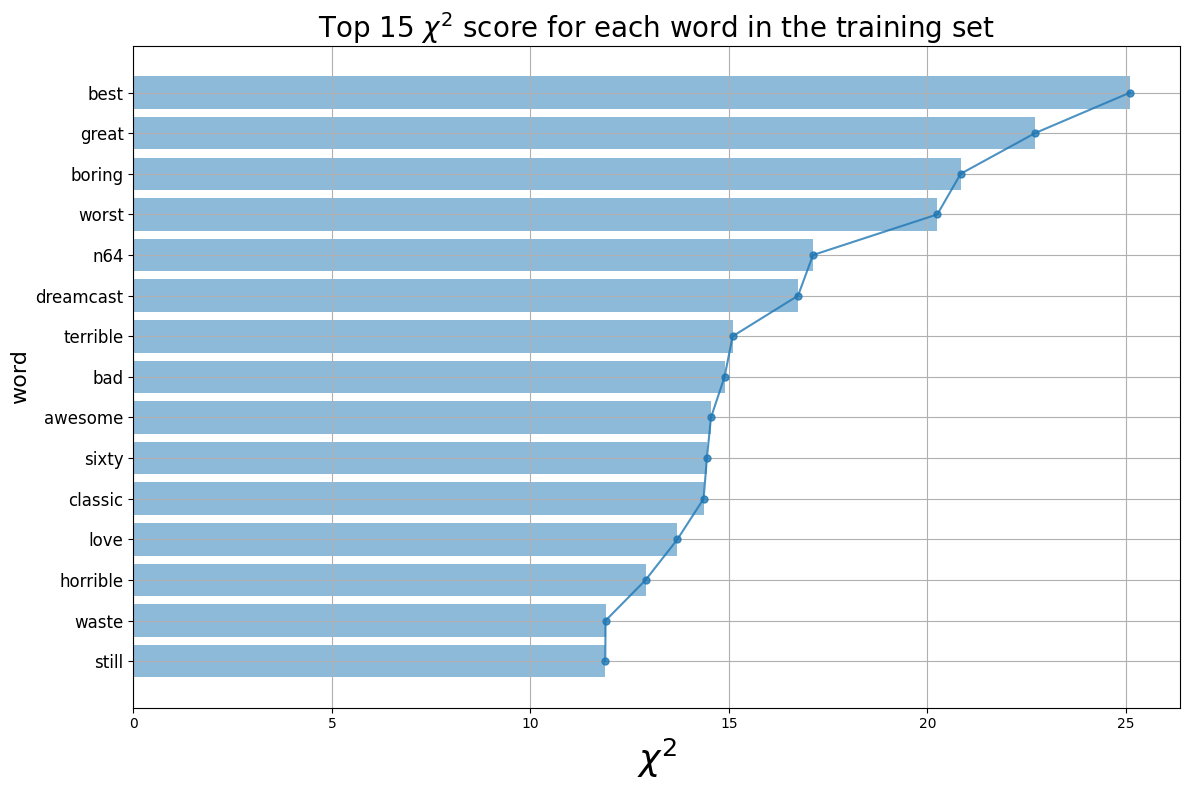

In [11]:
i = 15

chi2score = chi2(X_train_, y_train)[0]
scores = list(zip(cv.get_feature_names_out(), chi2score))
sorted_scores = sorted(scores, key=lambda x: x[1])
topchi2 = list(zip(*sorted_scores[-i:]))
x = range(len(topchi2[1]))
labels = topchi2[0]

plt.figure(figsize=(12, 8))
plt.barh(x, topchi2[1], align='center', alpha=0.5)
plt.plot(topchi2[1], x, '-o', markersize=5, alpha=0.8)
plt.yticks(x, labels, fontsize=12)
plt.xlabel('$\chi^2$', fontsize=26)
plt.ylabel('word', fontsize=16)
plt.title('Top {} $\chi^2$ score for each word in the training set'.format(i), fontsize=20)
plt.grid()
plt.tight_layout()
plt.show()

# 4. Modelo 1: Regresión Logística

Busco el mejor valor de C (parámetro de regularización) probando varios valores.
- C grande → menos regularización, el modelo se ajusta más al train (riesgo de overfitting)
- C pequeño → más regularización, el modelo es más simple (riesgo de underfitting)

In [12]:
c_params = [0.01, 0.05, 0.25, 0.5, 1, 10, 100, 1000, 10000]

train_acc = list()
test_acc  = list()

for c in c_params:
    lr = LogisticRegression(C=c, solver='lbfgs', max_iter=500)
    lr.fit(X_train_, y_train)

    train_predict = lr.predict(X_train_)
    test_predict  = lr.predict(X_test_)

    print('Accuracy for C={}: {}'.format(c, accuracy_score(y_test, test_predict)))

    train_acc.append(accuracy_score(y_train, train_predict))
    test_acc.append(accuracy_score(y_test, test_predict))

Accuracy for C=0.01: 0.776
Accuracy for C=0.05: 0.8384
Accuracy for C=0.25: 0.86
Accuracy for C=0.5: 0.8656
Accuracy for C=1: 0.868
Accuracy for C=10: 0.8728
Accuracy for C=100: 0.8592
Accuracy for C=1000: 0.8648
Accuracy for C=10000: 0.8672


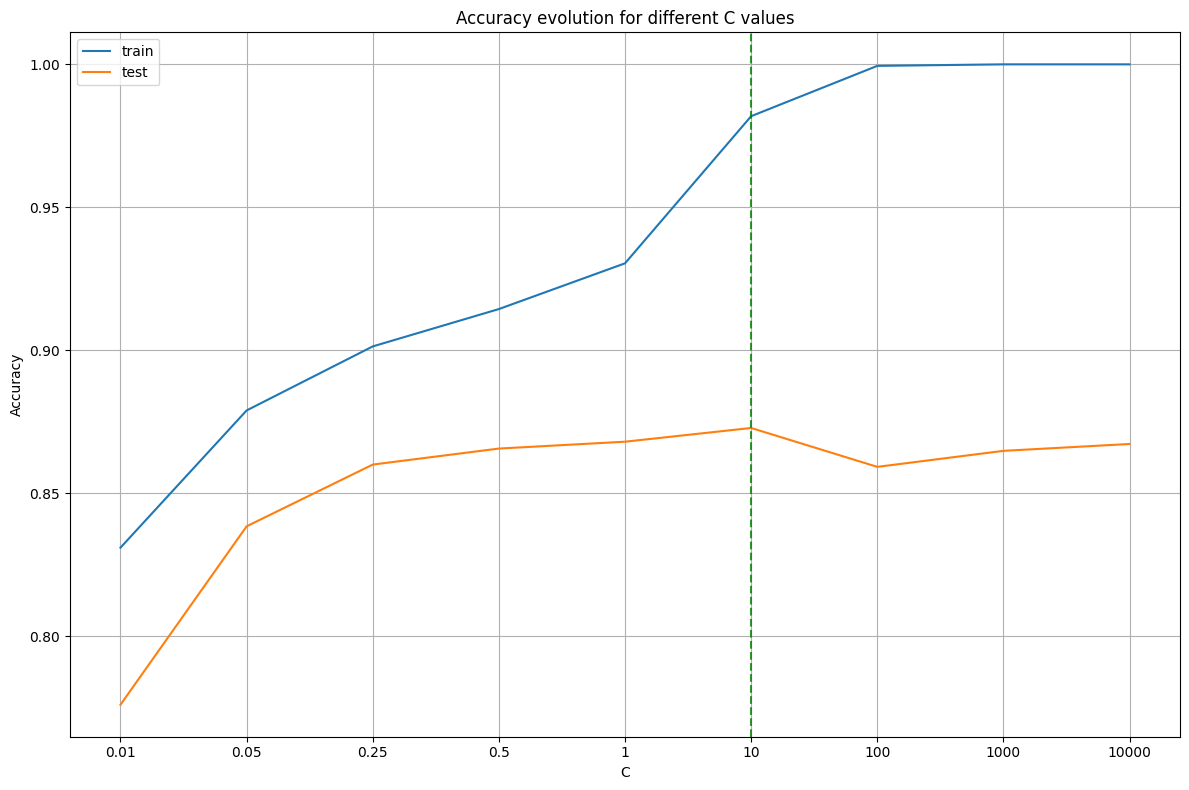

In [13]:
# Pinto la evolución del accuracy para los distintos valores de C
plt.figure(figsize=(12, 8))
plt.plot(train_acc, label='train')
plt.plot(test_acc, label='test')
plt.axvline(np.argmax(test_acc), c='g', ls='--', alpha=0.8)
plt.title('Accuracy evolution for different C values')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.xticks(list(range(len(c_params))), c_params)
plt.tight_layout()
plt.show()

In [14]:
# Entreno el modelo final con el mejor C
best_c = c_params[np.argmax(test_acc)]
print(f'Mejor C: {best_c}')

lr = LogisticRegression(C=best_c, solver='lbfgs', max_iter=500)
lr.fit(X_train_, y_train)
test_predict = lr.predict(X_test_)

Mejor C: 10


In [15]:
# Métricas del modelo
print('Confussion matrix:\n{}'.format(confusion_matrix(y_test, test_predict)))
print('\nClassification report:\n{}'.format(classification_report(y_test, test_predict)))
print('Accuracy score: {}'.format(accuracy_score(y_test, test_predict)))

Confussion matrix:
[[570  84]
 [ 75 521]]

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       654
           1       0.86      0.87      0.87       596

    accuracy                           0.87      1250
   macro avg       0.87      0.87      0.87      1250
weighted avg       0.87      0.87      0.87      1250

Accuracy score: 0.8728


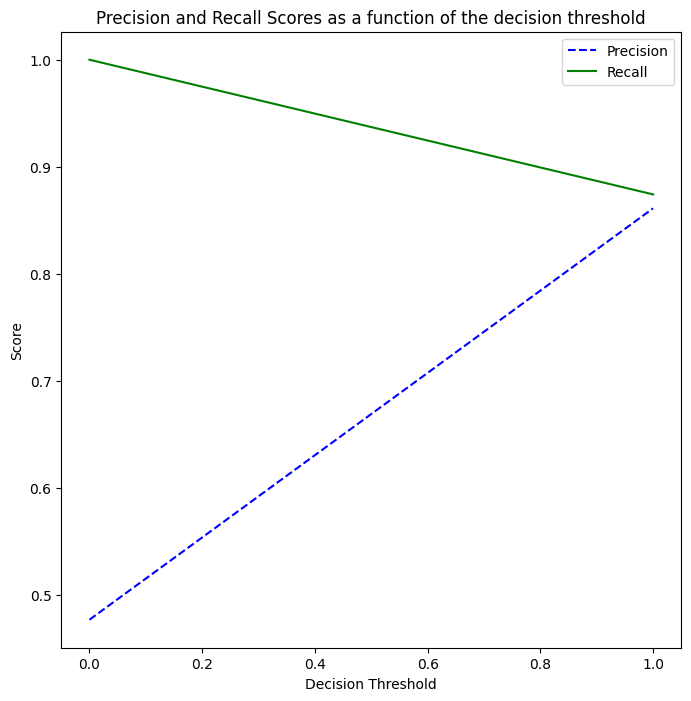

In [16]:
# Curva Precision-Recall - igual que en clase
p, r, thresholds = precision_recall_curve(y_test, test_predict)

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.figure(figsize=(8, 8))
    plt.title('Precision and Recall Scores as a function of the decision threshold')
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
    plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
    plt.ylabel('Score')
    plt.xlabel('Decision Threshold')
    plt.legend(loc='best')

plot_precision_recall_vs_threshold(p, r, thresholds)

In [17]:
# Predicción sobre reviews aleatorias - igual que en clase
def predict_review_sentiment(review_index, model):
    print('Actual sentiment: {}'.format(df.iloc[review_index]['label']))
    r = df.iloc[review_index]['text_clean']
    print('Prediction: {}'.format(model.predict(cv.transform([r]))))

for i in random.sample(range(0, len(df)), 5):
    print('\nReview no. {}'.format(i))
    predict_review_sentiment(i, lr)


Review no. 3850
Actual sentiment: 1
Prediction: [1]

Review no. 234
Actual sentiment: 1
Prediction: [1]

Review no. 2950
Actual sentiment: 1
Prediction: [1]

Review no. 1520
Actual sentiment: 0
Prediction: [0]

Review no. 4528
Actual sentiment: 1
Prediction: [1]


# 5. Modelo 2: LSTM (Deep Learning)

Uso una red neuronal recurrente con LSTM, igual que en el notebook 14 de clase.
El modelo aprende representaciones de las palabras en orden, teniendo en cuenta el contexto de la secuencia.


In [18]:
# Parámetros del modelo
vocabulary_size = 5000   # número máximo de palabras del vocabulario
max_words       = 500  # longitud máxima de cada secuencia
embedding_size  = 32  # dimensión de los embeddings
batch_size      = 64 # muestras por paso de entrenamiento
num_epochs      = 3

In [19]:
# Tokenizo con Keras - aprende el vocabulario del train
tokenizer_keras = Tokenizer(num_words=vocabulary_size)
tokenizer_keras.fit_on_texts(X_train)

print(f'Vocabulario Keras: {len(tokenizer_keras.word_index)} palabras')

Vocabulario Keras: 20144 palabras


In [20]:
# Convierto los textos a secuencias de índices y aplicamos padding
# pad_sequences rellena con 0s las secuencias más cortas hasta maxlen
X_train_seq = pad_sequences(tokenizer_keras.texts_to_sequences(X_train), maxlen=max_words)
X_test_seq  = pad_sequences(tokenizer_keras.texts_to_sequences(X_test),  maxlen=max_words)

print(f'Shape X_train: {X_train_seq.shape}')
print(f'Shape X_test:  {X_test_seq.shape}')

Shape X_train: (3750, 500)
Shape X_test:  (1250, 500)


In [21]:
# Construyo el modelo igual que en el notebook 14 de clase
# Embedding: aprende representaciones vectoriales de las palabras
# LSTM(100): red recurrente que captura dependencias en la secuencia
# Dense(1, sigmoid): salida binaria (0 o 1)
model = Sequential()
model.add(Embedding(vocabulary_size, embedding_size, input_length=max_words))
model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [22]:
# Compilo
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [23]:
# Split de validación
X_valid, y_valid   = X_train_seq[:batch_size], y_train.values[:batch_size]
X_train2, y_train2 = X_train_seq[batch_size:], y_train.values[batch_size:]

model.fit(
    X_train2, y_train2,
    validation_data=(X_valid, y_valid),
    batch_size=batch_size,
    epochs=num_epochs
)

Epoch 1/3
58/58 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.6267 - loss: 0.6567 - val_accuracy: 0.7344 - val_loss: 0.5571
Epoch 2/3
58/58 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.8378 - loss: 0.4094 - val_accuracy: 0.8125 - val_loss: 0.4161
Epoch 3/3
58/58 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.8877 - loss: 0.2875 - val_accuracy: 0.8281 - val_loss: 0.3728


In [24]:
# Evaluo el modelo en test
scores = model.evaluate(X_test_seq, y_test.values, verbose=0)
print('Test accuracy: {}'.format(scores[1]))

Test accuracy: 0.8384000062942505


In [25]:
# Métricas completas igual que en el modelo de ML
y_pred_dl = (model.predict(X_test_seq) > 0.5).astype(int)

print('Confussion matrix:\n{}'.format(confusion_matrix(y_test, y_pred_dl)))
print('\nClassification report:\n{}'.format(classification_report(y_test, y_pred_dl)))
print('Accuracy score: {}'.format(accuracy_score(y_test, y_pred_dl)))

40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 327ms/step
Confussion matrix:
[[557  97]
 [105 491]]

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       654
           1       0.84      0.82      0.83       596

    accuracy                           0.84      1250
   macro avg       0.84      0.84      0.84      1250
weighted avg       0.84      0.84      0.84      1250

Accuracy score: 0.8384


In [26]:
# Guardamos el modelo de Deep Learning
model.save('lstm_model.h5')
print('Guardado: lstm_model.h5')

Guardado: lstm_model.h5


# 6. Comparación de modelos

Pinto los modelos para compararlos.

=== COMPARACIÓN DE MODELOS ===
Regresión Logística (TF-IDF): 0.8728
LSTM (Deep Learning):          0.8384

Mejor modelo: Regresión Logística


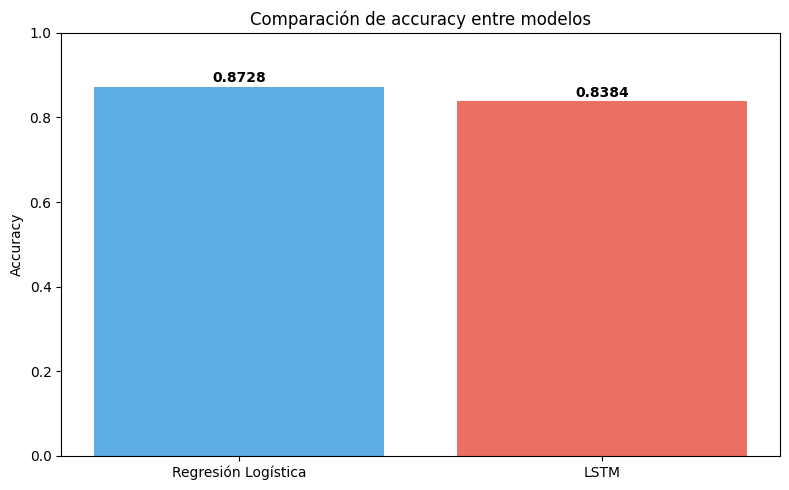

In [27]:
acc_lr = accuracy_score(y_test, test_predict)
acc_dl = accuracy_score(y_test, y_pred_dl)

print('=== COMPARACIÓN DE MODELOS ===')
print(f'Regresión Logística (TF-IDF): {acc_lr:.4f}')
print(f'LSTM (Deep Learning):          {acc_dl:.4f}')
print(f'\nMejor modelo: {"Regresión Logística" if acc_lr > acc_dl else "LSTM"}')

modelos = ['Regresión Logística', 'LSTM']
accuracies = [acc_lr, acc_dl]

plt.figure(figsize=(8, 5))
plt.bar(modelos, accuracies, color=['#3498db', '#e74c3c'], alpha=0.8)
plt.ylim(0, 1)
plt.title('Comparación de accuracy entre modelos')
plt.ylabel('Accuracy')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 7. Posible mejora

Veo que la regresión logística tiene mejores resultados que la LSTM, voy a intentar mejorar la LSTM con EarlyStopping para que coja las epochs que considere el modelo cuando vea que el acuraccy baja.

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

model_es = Sequential()
model_es.add(Embedding(vocabulary_size, embedding_size, input_length=max_words))
model_es.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
model_es.add(Dense(1, activation='sigmoid'))

model_es.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [29]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True) #Espero 2 epochs sin mejora para parar y recupero los pesos del mejor epoch.

history = model_es.fit(
    X_train2, y_train2,
    validation_data=(X_valid, y_valid),
    batch_size=batch_size,
    epochs=10,  # Subo epochs porque EarlyStopping decide cuándo parar
    callbacks=[early_stop]
)

print(f'EarlyStopping paró en el epoch {len(history.history["loss"])} de 10 disponibles')

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.6047 - loss: 0.6581 - val_accuracy: 0.7812 - val_loss: 0.4899
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.8454 - loss: 0.3926 - val_accuracy: 0.7969 - val_loss: 0.4271
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9072 - loss: 0.2424 - val_accuracy: 0.8125 - val_loss: 0.4053
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9387 - loss: 0.1709 - val_accuracy: 0.8594 - val_loss: 0.3875
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9577 - loss: 0.1165 - val_accuracy: 0.7344 - val_loss: 0.5643
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9601 - loss: 0.1202 - val_accuracy: 0.8594 - val_loss: 0.5250
EarlyStopping paró en el epoch 6 de 10 disponibles


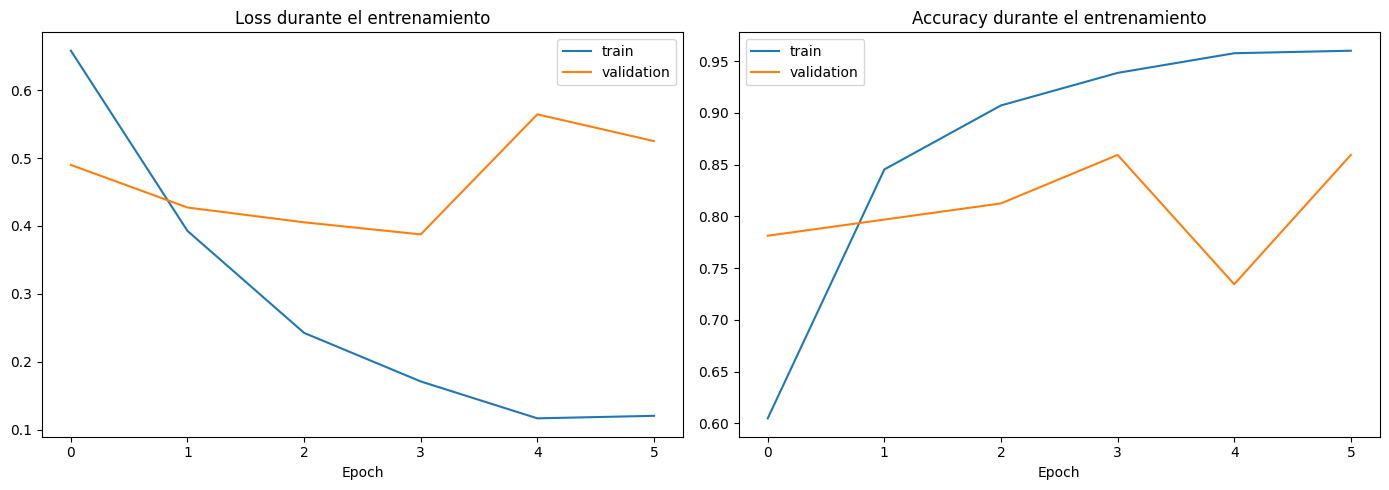

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='validation')
axes[0].set_title('Loss durante el entrenamiento')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='validation')
axes[1].set_title('Accuracy durante el entrenamiento')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [31]:
y_pred_es = (model_es.predict(X_test_seq) > 0.5).astype(int)
acc_dl_es = accuracy_score(y_test, y_pred_es)

print(f'Accuracy LSTM + EarlyStopping: {acc_dl_es:.4f}')
print(classification_report(y_test, y_pred_es))

40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 322ms/step
Accuracy LSTM + EarlyStopping: 0.8448
              precision    recall  f1-score   support

           0       0.87      0.82      0.85       654
           1       0.82      0.87      0.84       596

    accuracy                           0.84      1250
   macro avg       0.85      0.85      0.84      1250
weighted avg       0.85      0.84      0.84      1250



                         Modelo  Accuracy
0  Regresión Logística (TF-IDF)    0.8728
1      LSTM (sin EarlyStopping)    0.8384
2      LSTM (con EarlyStopping)    0.8448


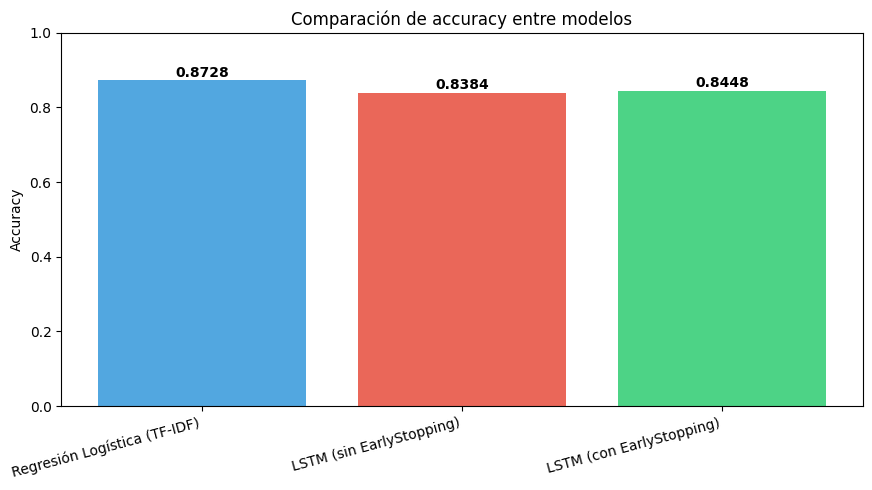

In [32]:
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística (TF-IDF)', 'LSTM (sin EarlyStopping)', 'LSTM (con EarlyStopping)'],
    'Accuracy': [acc_lr, acc_dl, acc_dl_es]
})

print(resultados)

plt.figure(figsize=(9, 5))
plt.bar(resultados['Modelo'], resultados['Accuracy'], color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.85)
plt.ylim(0, 1)
plt.title('Comparación de accuracy entre modelos')
plt.ylabel('Accuracy')
plt.xticks(rotation=15, ha='right')
for i, v in enumerate(resultados['Accuracy']):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()